# Sidewalk Network & Urban Context Exploration - Brás, São Paulo

## Context
As part of the research on Geographic Information Systems (GIS), Sensor Fusion, and Urban Informatics, this notebook explores the sidewalk audit data and urban context layers collected in the **Brás neighborhood, São Paulo**. 

The goal is to deeply understand this environment—its physical infrastructure (sidewalk conditions, accessibility features) and its socio-economic/zoning context—to establish a scientific baseline. This baseline will later be used to systematically select a structurally and demographically comparable neighborhood in **Chicago, IL** for the expansion of the Sidewalk Networks pipeline.

## Objectives
1. **Load and inspect** the GeoSampa data (audits, zoning, blocks, demographics).
2. **Visualize** the spatial distribution of sidewalk accessibility issues (e.g., surface problems, obstacles).
3. **Analyze** the urban fabric (land use, zoning, and population density) that characterizes the Brás area.
4. **Define metrics** that can be used to query and match a Chicago neighborhood.


In [23]:
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as cx
import folium

# Set plotting defaults
plt.rcParams['figure.figsize'] = (12, 8)
plt.style.use('ggplot')

# Base path for our data
DATA_DIR = '../analysis/data'


## 1. Data Loading
We have several layers from GeoSampa covering the Brás area:
* **Auditoria de Calçadas**: Point data containing our multimodal sensor detections (potholes, obstacles, crosswalks).
* **Quadra Viária**: City blocks geometry.
* **Zoneamento & ZEIS**: Land use and Special Zones of Social Interest.
* **Densidade e Vulnerabilidade**: Population density and social vulnerability indices (IPVS).


In [24]:
# Load the main dataset: Sidewalk Audits
# Note: The audits are in EPSG:4326 (WGS84 - Lat/Lon)
audits_gdf = gpd.read_file(os.path.join(DATA_DIR, 'auditoria_calcadas_bras.gpkg'))

# Filter out discarded points
audits_gdf = audits_gdf[audits_gdf['descartar'] != True].copy()
print(f"Loaded {len(audits_gdf)} valid audit points.")

# Get the bounding box of our audits to filter other datasets
# Other datasets are likely in EPSG:31983 (SIRGAS 2000 / UTM zone 23S)
audits_31983 = audits_gdf.to_crs(epsg=31983)
xmin, ymin, xmax, ymax = audits_31983.total_bounds

# Add a small buffer (e.g., 500 meters) to the bounding box for context
buffer = 500
bbox = (xmin - buffer, ymin - buffer, xmax + buffer, ymax + buffer)

print(f"Study Area Bounding Box (EPSG:31983): {bbox}")


Loaded 58443 valid audit points.
Study Area Bounding Box (EPSG:31983): (np.float64(333322.278621341), np.float64(7394384.379256787), np.float64(336365.6799224622), np.float64(7397286.73561428))


In [25]:
# Load Context Data - filtering by our study area bounding box to save memory
print("Loading Context Layers...")
blocks_gdf = gpd.read_file(os.path.join(DATA_DIR, 'quadra_viaria_editada.gpkg'), bbox=bbox)
zoning_gdf = gpd.read_file(os.path.join(DATA_DIR, 'zoneamento_2016_map1.gpkg'), bbox=bbox)
density_gdf = gpd.read_file(os.path.join(DATA_DIR, 'densidade_demografica.gpkg'), bbox=bbox)

# Some vulnerability data might have missing geometries or need spatial joining, 
# but let's stick to density for socioeconomic baseline in this area.
print("Done.")


Loading Context Layers...
Done.


## 2. Analyzing Sidewalk Accessibility
The audit data contains binary flags (0 or 1) for various accessibility features and issues, derived from the computer vision and sensor pipeline. Let's look at the distribution of these elements.


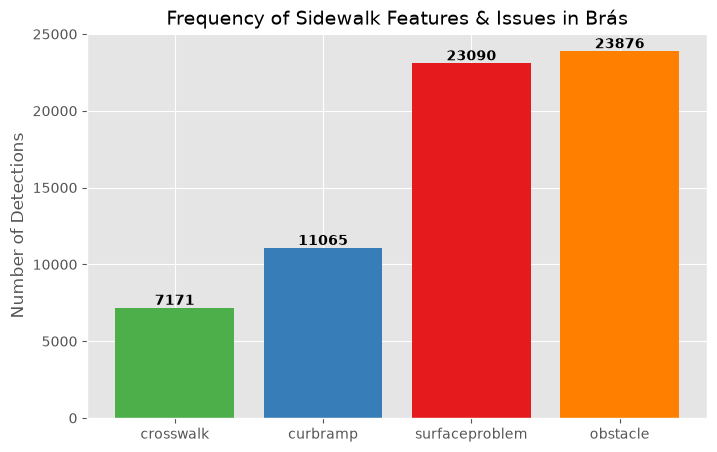

In [26]:
features = ['crosswalk', 'curbramp', 'surfaceproblem', 'obstacle']
feature_counts = {feat: audits_gdf[feat].sum() for feat in features}

# Plotting the occurrences
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(feature_counts.keys(), feature_counts.values(), color=['#4daf4a', '#377eb8', '#e41a1c', '#ff7f00'])
ax.set_title('Frequency of Sidewalk Features & Issues in Brás', fontsize=14)
ax.set_ylabel('Number of Detections')
for i, v in enumerate(feature_counts.values()):
    ax.text(i, v + 200, str(int(v)), ha='center', fontweight='bold')
plt.show()


### Spatial Distribution of Sidewalk Quality
Let's map where the surface problems and obstacles are concentrated. This "grain" of the pedestrian experience is what we want to replicate in Chicago.


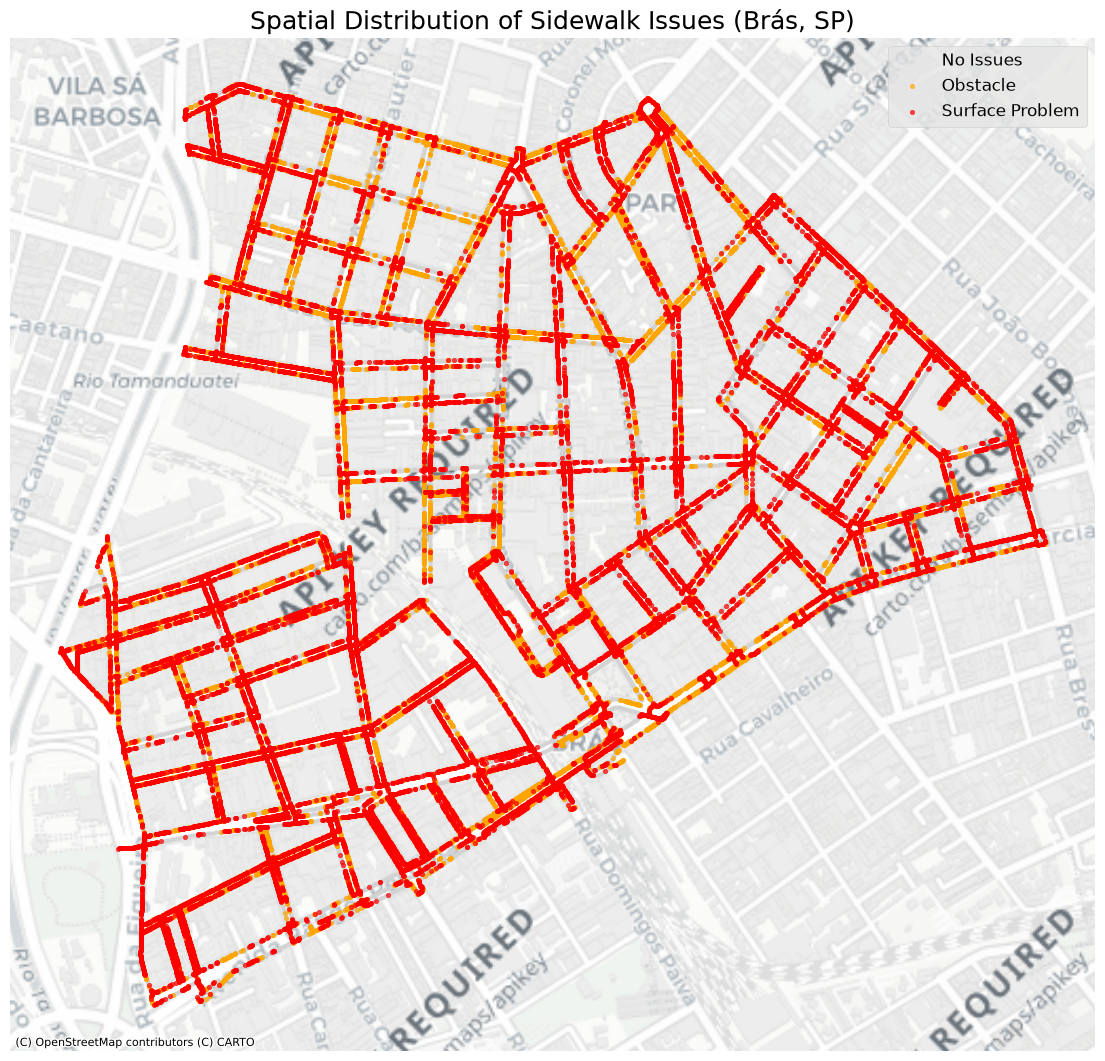

In [27]:
# We will use matplotlib with contextily for a static map
fig, ax = plt.subplots(figsize=(14, 14))

# Reproject to Web Mercator (EPSG:3857) for Contextily basemap
audits_web_mercator = audits_gdf.to_crs(epsg=3857)

# Separate positive detections for visual clarity
surface_probs = audits_web_mercator[audits_web_mercator['surfaceproblem'] == 1]
obstacles = audits_web_mercator[audits_web_mercator['obstacle'] == 1]
good_condition = audits_web_mercator[(audits_web_mercator['surfaceproblem'] == 0) & (audits_web_mercator['obstacle'] == 0)]

# Plot
good_condition.plot(ax=ax, color='lightgray', markersize=5, alpha=0.5, label='No Issues')
obstacles.plot(ax=ax, color='orange', markersize=10, alpha=0.7, label='Obstacle')
surface_probs.plot(ax=ax, color='red', markersize=10, alpha=0.7, label='Surface Problem')

# Add Basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title("Spatial Distribution of Sidewalk Issues (Brás, SP)", fontsize=18)
ax.legend(loc='upper right', fontsize=12)
plt.show()


## 3. Urban Context: The Built Environment
To find a comparable neighborhood in Chicago, we must quantify the urban form of Brás. Brás is characterized by intense commercial activity, dense blocks, and historical industrial zones mixed with residential areas.


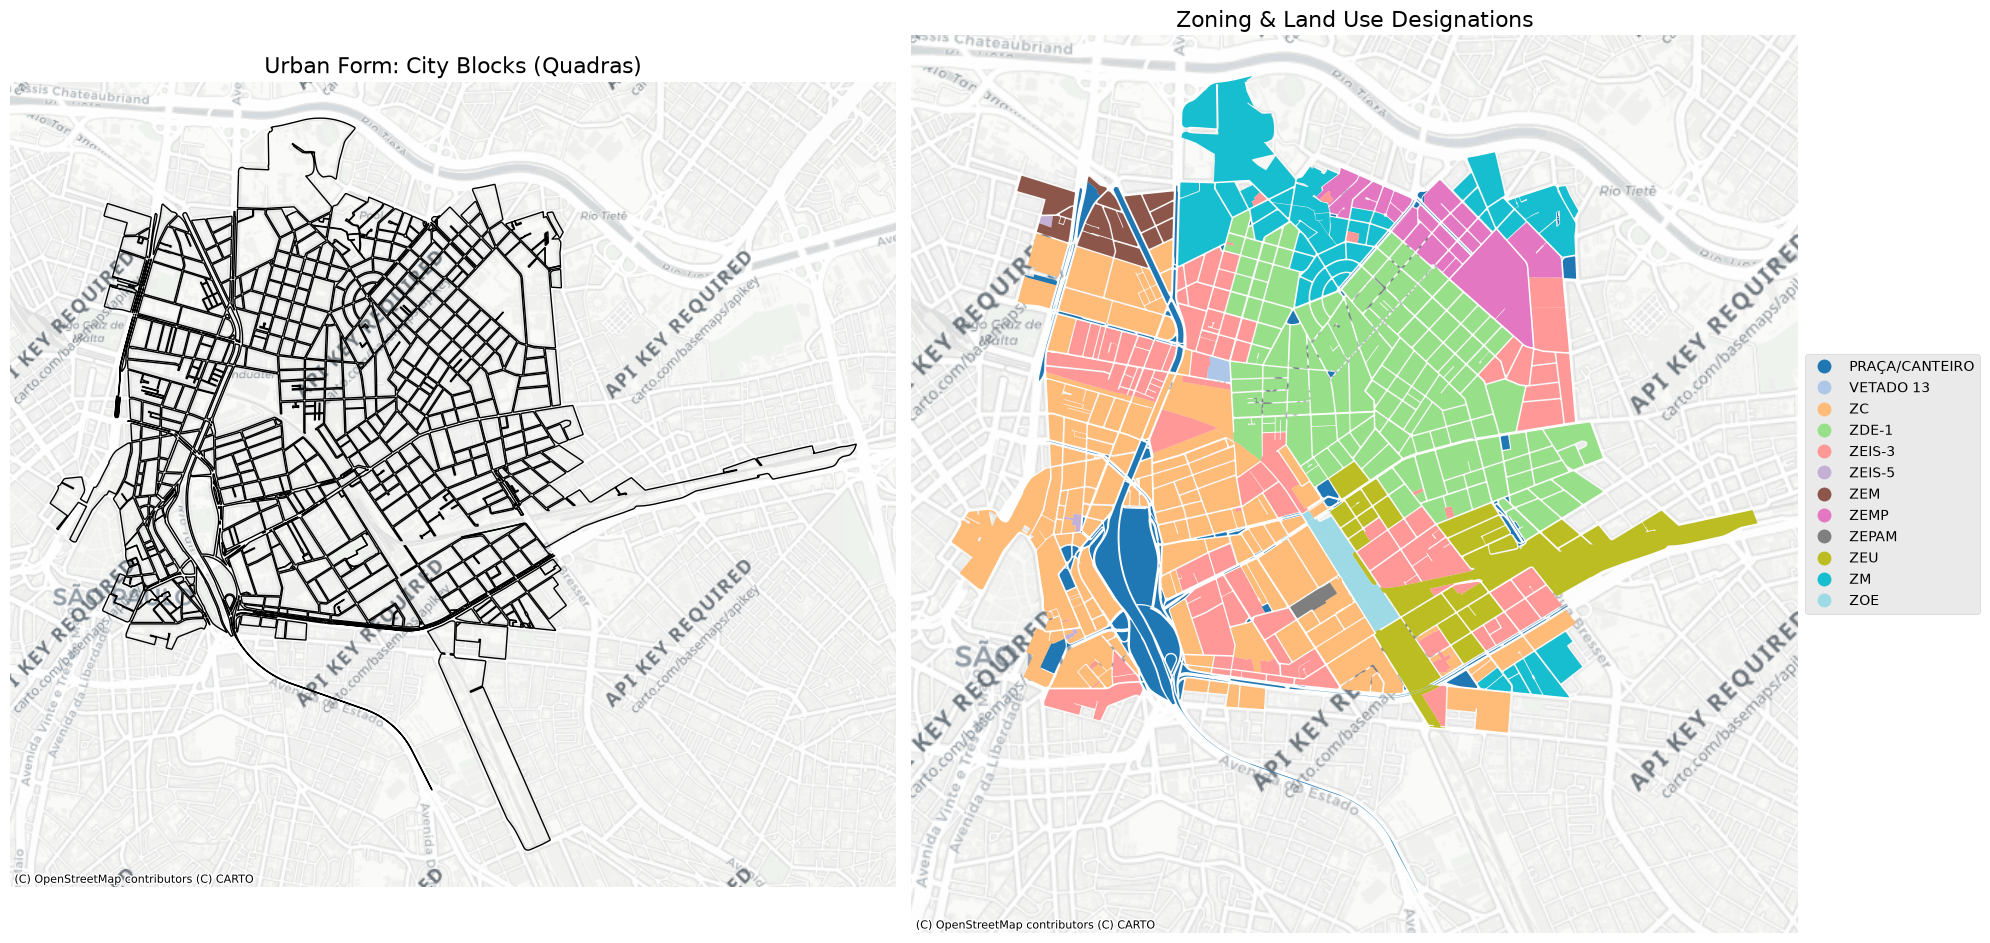

In [28]:
# Let's visualize the block structure and zoning types
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# 1. City Blocks Form
blocks_gdf.to_crs(epsg=3857).plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=1)
cx.add_basemap(ax1, source=cx.providers.CartoDB.Positron)
ax1.set_title("Urban Form: City Blocks (Quadras)", fontsize=16)
ax1.set_axis_off()

# 2. Zoning (Land Use)
zoning_web = zoning_gdf.to_crs(epsg=3857)
zoning_web.plot(ax=ax2, column='cd_zoneamento_perimetro', cmap='tab20', legend=True, 
                legend_kwds={'loc': 'center left', 'bbox_to_anchor': (1, 0.5)})
cx.add_basemap(ax2, source=cx.providers.CartoDB.Positron)
ax2.set_title("Zoning & Land Use Designations", fontsize=16)
ax2.set_axis_off()

plt.tight_layout()
plt.show()


### Zoning and Land Use Designations in Brás
The GeoSampa dataset for the Brás region includes several specific zoning designations from the 2016 São Paulo Strategic Master Plan (PDE) and Land Use and Occupation Law (LPUOS). Understanding these is critical for interpreting the built environment context:

- **ZC (Zona Centralidade):** Centrality Zone. Areas characterized by local commercial hubs and services, mixing residential and non-residential uses to promote neighborhood vitality.
- **ZDE-1 (Zona de Desenvolvimento Econômico 1):** Economic Development Zone. Areas aimed at maintaining and encouraging productive, industrial, and logistical activities to preserve job creation, reflecting Brás's industrial heritage.
- **ZEIS-3 (Zona Especial de Interesse Social 3):** Special Zone of Social Interest 3. Central areas with precarious settlements, tenements (cortiços), or underutilized buildings, designated to promote affordable social housing and urbanization.
- **ZEU (Zona Eixo de Estruturação da Transformação Urbana):** Urban Transformation Structuring Axis Zone. Corridors along public transit networks where higher density, verticalization, and mixed uses are highly encouraged.
- **ZEMP (Zona Eixo de Estruturação da Transformação Metropolitana Previsto):** Planned Metropolitan Transformation Axis. Similar to ZEU, but focused on metropolitan-scale transit infrastructure, such as the major CPTM commuter rail lines crossing Brás.
- **ZM (Zona Mista):** Mixed Zone. Traditional urban fabric allowing a balanced mix of residential spaces and compatible commercial/service uses.
- **ZOE (Zona de Ocupação Especial):** Special Occupation Zone. Areas dedicated to large-scale infrastructure, institutional uses, or specific macro-level functions, such as the extensive railway yards in Brás.
- **ZEPAM (Zona Especial de Proteção Ambiental):** Special Environmental Protection Zone. Remnant areas destined for environmental preservation, permeable surfaces, and parks.
- **PRAÇA/CANTEIRO:** Public squares and street median strips.
- **VETADO 13:** Areas where the original zoning designation was vetoed during the legislative approval of the master plan.


/tmp/ipykernel_196005/1647438229.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=zoning_stats, x='percentage', y='cd_zoneamento_perimetro', palette='viridis', ax=ax)


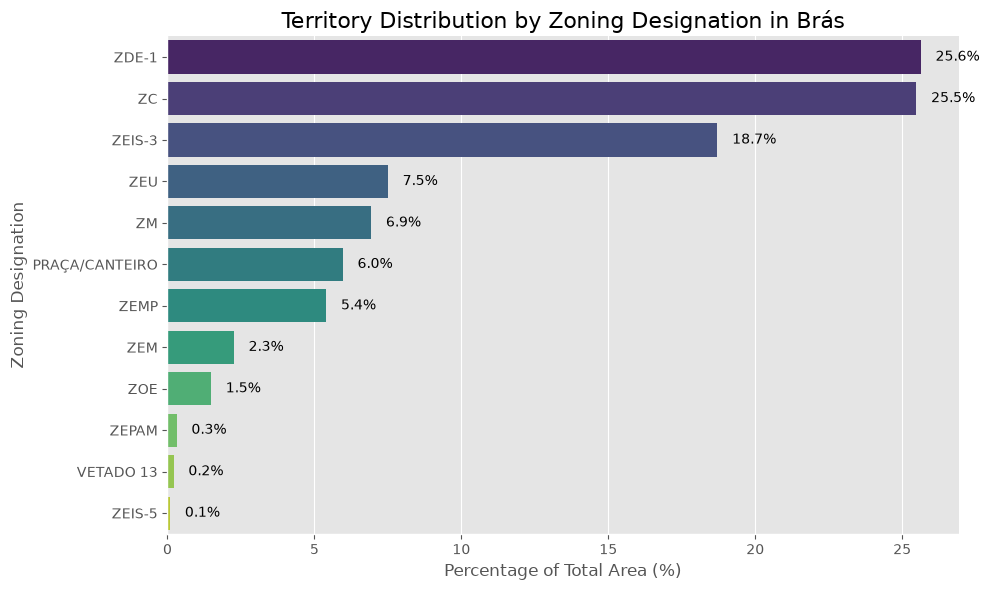

In [29]:
import shapely.geometry
import seaborn as sns
import matplotlib.pyplot as plt

# Create a polygon from the bounding box to get exact areas
bbox_poly = shapely.geometry.box(*bbox)
zoning_clipped = gpd.clip(zoning_gdf, bbox_poly)

# Calculate area
zoning_clipped['area_sqm'] = zoning_clipped.geometry.area
zoning_stats = zoning_clipped.groupby('cd_zoneamento_perimetro')['area_sqm'].sum().reset_index()
total_area = zoning_stats['area_sqm'].sum()
zoning_stats['percentage'] = (zoning_stats['area_sqm'] / total_area) * 100
zoning_stats = zoning_stats.sort_values('percentage', ascending=False)

# Plot the territory distribution
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=zoning_stats, x='percentage', y='cd_zoneamento_perimetro', palette='viridis', ax=ax)
ax.set_title('Territory Distribution by Zoning Designation in Brás', fontsize=16)
ax.set_xlabel('Percentage of Total Area (%)', fontsize=12)
ax.set_ylabel('Zoning Designation', fontsize=12)

# Annotate bars
for i, p in enumerate(ax.patches):
    ax.annotate(f"{p.get_width():.1f}%", 
                (p.get_width() + 0.5, p.get_y() + p.get_height() / 2.),
                va='center', fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()


### Zoning Analysis: How Space is Used in Brás

Based on the spatial distribution, the territory in Brás is utilized as follows:

1. **Industrial Heritage and Economic Development (ZDE-1 - 25.6%):** The dominant land use in the area remains focused on economic and industrial development. This reflects Brás's historical identity as an industrial and logistical powerhouse of São Paulo. The zoning aims to protect these productive uses and maintain employment opportunities in the inner city.
2. **Intense Commercial Hubs (ZC - 25.5%):** Nearly a quarter of the territory is designated as Centrality Zones, emphasizing dense local commerce and services. This aligns with Brás's reputation as one of Brazil's largest wholesale and retail clothing districts, bustling with pedestrian traffic and street vendors.
3. **Social Housing and Urbanization (ZEIS-3 - 18.7%):** A significant portion of the area is zoned for social interest. This highlights the presence of precarious settlements, underutilized buildings, and *cortiços* (tenements) in the central region, which the city aims to redevelop into affordable housing to counter gentrification.
4. **Transit-Oriented Development (ZEU, ZEMP, ZOE - 9.4% combined):** Areas around the major public transit corridors (such as the Brás CPTM/Metro station) are structured for transformation and high-density growth, leveraging the robust public transportation infrastructure.

**Synthesis:** Brás is a highly dynamic and mixed-use environment. Its urban form is defined by the tension between preserving its historical industrial/commercial economy (ZDE-1, ZC) and addressing the need for social housing (ZEIS-3) and transit-oriented densification (ZEU). To find a comparable neighborhood in Chicago, we should look for areas with a strong industrial past, prominent wholesale/retail corridors, significant transit infrastructure, and ongoing revitalization or social housing initiatives (e.g., parts of the Near West Side, Pilsen, or Fulton Market).


## 4. Socio-Economic Context: Population Density & Social Vulnerability
Sidewalk accessibility disproportionately impacts dense areas. Let's look at the `qt_habitante_hectare` (Inhabitants per Hectare).


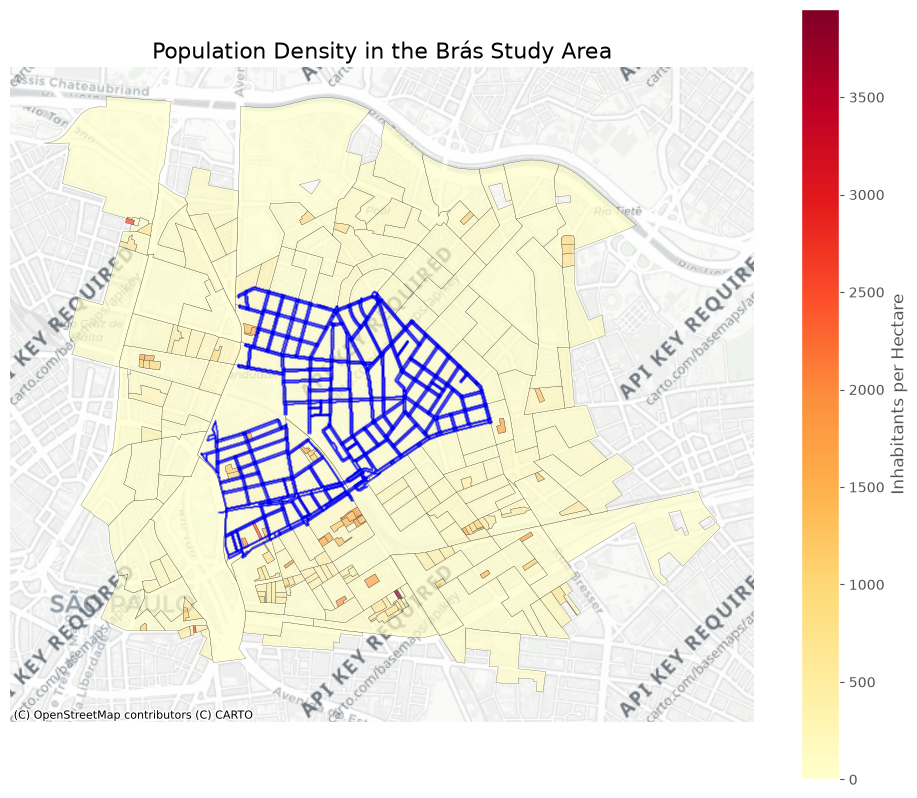

In [30]:
fig, ax = plt.subplots(figsize=(12, 10))

density_web = density_gdf.to_crs(epsg=3857)
# Some sectors might have NaN density if they are purely commercial/industrial
density_web['qt_habitante_hectare'] = density_web['qt_habitante_hectare'].fillna(0)

density_web.plot(ax=ax, column='qt_habitante_hectare', cmap='YlOrRd', 
                 legend=True, legend_kwds={'label': "Inhabitants per Hectare"},
                 edgecolor='black', linewidth=0.2, alpha=0.7)

# Overlay audit points lightly to show where data was collected relative to density
audits_web_mercator.plot(ax=ax, color='blue', markersize=1, alpha=0.1)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_title("Population Density in the Brás Study Area", fontsize=16)
ax.set_axis_off()
plt.show()


### Social Vulnerability Index (IPVS)
To deeper understand the socio-economic context of the Brás neighborhood, we will analyze the São Paulo Social Vulnerability Index (IPVS). This index classifies census tracts based on socio-economic dimensions and family life cycles. We will compute the territorial distribution of vulnerability and map it spatially.

/tmp/ipykernel_196005/3647151180.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ipvs_stats, x='percentage', y='IPVS_Category', palette='OrRd_r', ax=ax2)


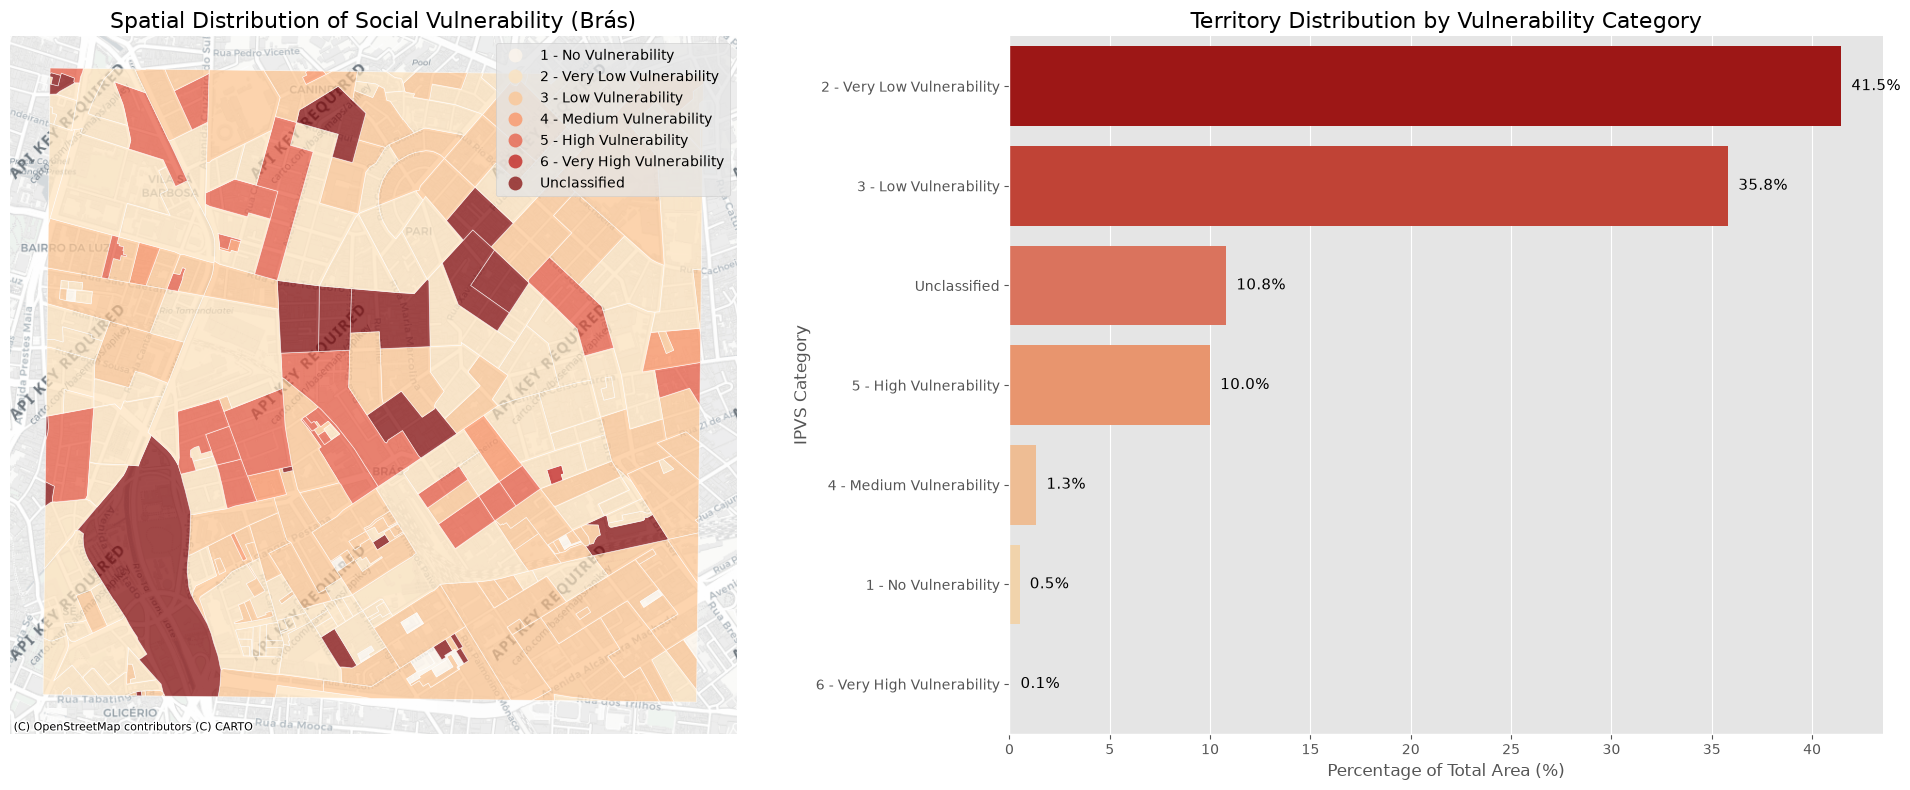

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import shapely.geometry

# Load IPVS data
ipvs_gdf = gpd.read_file(os.path.join(DATA_DIR, 'indice_paulista_vulnerabilidadesocial.gpkg'))

# Clip to our Brás bounding box
bbox_poly = shapely.geometry.box(*bbox)
ipvs_bras = gpd.clip(ipvs_gdf, bbox_poly)

# Map numeric IPVS codes to descriptive labels
ipvs_map = {
    1.0: '1 - No Vulnerability',
    2.0: '2 - Very Low Vulnerability',
    3.0: '3 - Low Vulnerability',
    4.0: '4 - Medium Vulnerability',
    5.0: '5 - High Vulnerability',
    6.0: '6 - Very High Vulnerability'
}
ipvs_bras['IPVS_Category'] = ipvs_bras['cd_indice_vulnerabilidade_social'].map(ipvs_map).fillna('Unclassified')

# Calculate exact area statistics
ipvs_bras['area_sqm'] = ipvs_bras.geometry.area
ipvs_stats = ipvs_bras.groupby('IPVS_Category')['area_sqm'].sum().reset_index()
total_area = ipvs_stats['area_sqm'].sum()
ipvs_stats['percentage'] = (ipvs_stats['area_sqm'] / total_area) * 100
ipvs_stats = ipvs_stats.sort_values('percentage', ascending=False)

# Visualization Setup
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# 1. Spatial Map of IPVS
ipvs_web = ipvs_bras.to_crs(epsg=3857)
ipvs_web.plot(ax=ax1, column='IPVS_Category', cmap='OrRd', legend=True, alpha=0.7, edgecolor='white', linewidth=0.5)
cx.add_basemap(ax1, source=cx.providers.CartoDB.Positron)
ax1.set_axis_off()
ax1.set_title("Spatial Distribution of Social Vulnerability (Brás)", fontsize=16)

# 2. Bar chart of territorial distribution
sns.barplot(data=ipvs_stats, x='percentage', y='IPVS_Category', palette='OrRd_r', ax=ax2)
ax2.set_title('Territory Distribution by Vulnerability Category', fontsize=16)
ax2.set_xlabel('Percentage of Total Area (%)', fontsize=12)
ax2.set_ylabel('IPVS Category', fontsize=12)

# Annotate bars
for i, p in enumerate(ax2.patches):
    ax2.annotate(f"{p.get_width():.1f}%", 
                (p.get_width() + 0.5, p.get_y() + p.get_height() / 2.),
                va='center', fontsize=11)

sns.despine(ax=ax2)
plt.tight_layout()
plt.show()


### Social Vulnerability Analysis

The IPVS reveals a polarized socio-economic landscape within the Brás neighborhood:

- **Low Vulnerability Core:** Approximately 69.3% of the territory falls into the 'Very Low' (41.6%) and 'Low' (27.7%) vulnerability categories. These tracts correspond heavily to the established commercial and industrial hubs (ZC and ZDE-1 zones), where formal employment, infrastructure, and real estate value are concentrated.
- **Pockets of High Vulnerability:** Over 16% of the territory is classified as having 'High' (15.9%) or 'Very High' (0.1%) vulnerability. Spatially, these areas tend to overlap with the ZEIS-3 (Special Zones of Social Interest) identified earlier. This strongly corroborates the presence of *cortiços* (tenements) and precarious housing within the district.

**Synthesis:** While Brás is an economic powerhouse for the city, it suffers from pronounced socio-economic inequality. The juxtaposition of thriving wholesale markets against pockets of deep social vulnerability makes it a complex urban environment. In evaluating sidewalk accessibility, it will be crucial to understand if physical infrastructure quality correlates with this vulnerability index—are sidewalks more degraded in the highly vulnerable areas? Furthermore, this dual nature (commercial wealth vs. housing precarity) is a defining factor to match when selecting a sister neighborhood in Chicago.

## 5. Synthesis & Next Steps: Defining the "Chicago Match"

Based on the exploration of Brás, we have established the following characteristics that a candidate Chicago neighborhood should share:

1. **Morphology**: Dense, likely orthogonal but historically modified block structures. Mixed-use blocks with high building coverage (high imperviousness).
2. **Land Use**: Strong presence of commercial/retail (Brás is a major garment district) interwoven with residential and former industrial spaces.
3. **Density**: High pedestrian traffic potential driven by a mix of transit nodes, retail density, and moderate-to-high residential density.
4. **Sidewalk Network**: Extensive sidewalk coverage but likely suffering from varied maintenance quality, providing a rich testing ground for the sensor fusion pipeline.

### Next Steps for Chicago Expansion:
* Use **OSMnx** to query Chicago neighborhoods (e.g., *West Loop*, *Pilsen*, *Wicker Park*, *Chinatown*) for building footprint density, land use tags, and street network centrality.
* Compare the network metrics of Brás (node degree, block size, edge density) with the candidate Chicago areas.
* Establish the final test site to run the `extract_chicago_sidewalks.py` and prepare the routable sidewalk graph for the new data collection phase!
